# 01 — Data Preparation
**Engagement:** E-commerce Sales & Customer Analytics
**Business question this notebook answers:** Is the raw transactional data reliable enough to base revenue and customer-value conclusions on?

Source: [Online Retail II, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — real transactions, UK-based online retailer, Dec 2009–Dec 2011.

**Steps:** load → standardize columns → remove cancellations/invalid rows → compute revenue → save clean dataset for downstream notebooks.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_PATH = Path("../data/raw/online_retail_ii.xlsx")   # or .csv — see loader below
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load

The UCI file ships as a single `.xlsx` with two sheets (`Year 2009-2010`, `Year 2010-2011`). This loader also accepts a single `.csv` if you exported/merged it yourself — just point `RAW_PATH` at it.

In [2]:
def load_raw(path: Path) -> pd.DataFrame:
    if path.suffix == ".xlsx":
        sheets = pd.read_excel(path, sheet_name=None)
        df = pd.concat(sheets.values(), ignore_index=True)
    else:
        df = pd.read_csv(path)
    return df

df = load_raw(RAW_PATH)
print(f"Rows loaded: {len(df):,}")
df.head()

Rows loaded: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Standardize column names

Different distributions of this dataset (UCI vs. Kaggle mirrors) use slightly different column names
(`Invoice` vs `InvoiceNo`, `Price` vs `UnitPrice`, `Customer ID` vs `CustomerID`). This mapping makes the
pipeline robust to whichever version you downloaded.

In [3]:
RENAME_MAP = {
    "Invoice": "InvoiceNo", "InvoiceNo": "InvoiceNo",
    "Customer ID": "CustomerID", "CustomerID": "CustomerID",
    "Price": "UnitPrice", "UnitPrice": "UnitPrice",
    "StockCode": "StockCode", "Description": "Description",
    "Quantity": "Quantity", "InvoiceDate": "InvoiceDate", "Country": "Country",
}
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns=RENAME_MAP)

required = ["InvoiceNo", "StockCode", "Description", "Quantity",
            "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing expected columns after rename: {missing}"

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Columns OK:", list(df.columns))

Columns OK: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 3. Clean

Rules applied (standard practice for this dataset):
- Drop rows with no `CustomerID` — these are guest/unidentifiable transactions and can't be attributed to a customer for RFM/cohort analysis.
- Drop cancellations — `InvoiceNo` starting with `C` (or negative `Quantity`, as a safety net for mirrors that don't use the `C` prefix).
- Drop rows with non-positive `Quantity` or `UnitPrice` (returns, adjustments, data errors).

In [4]:
n_before = len(df)

df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

n_after = len(df)
print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after cleaning:  {n_after:,}  ({n_after/n_before:.1%} retained)")

Rows before cleaning: 1,067,371
Rows after cleaning:  805,549  (75.5% retained)


## 4. Quick sanity check — revenue by month

<Axes: title={'center': 'Monthly Revenue'}, xlabel='InvoiceDate'>

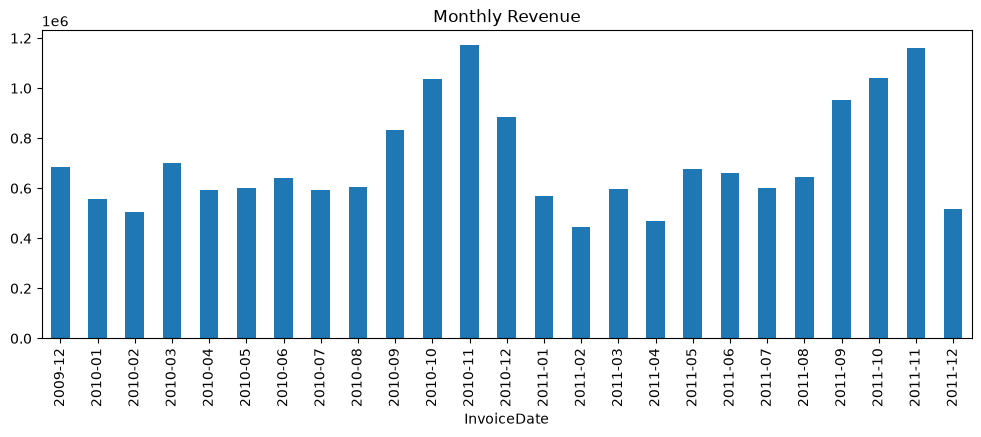

In [5]:
monthly_revenue = (
    df.set_index("InvoiceDate")["Revenue"]
      .resample("MS").sum()
)
monthly_revenue.index = monthly_revenue.index.strftime("%Y-%m")
monthly_revenue.plot(kind="bar", figsize=(12, 4), title="Monthly Revenue")

In [6]:
import matplotlib.pyplot as plt
plt.gcf().savefig('../figures/monthly_revenue.png', dpi=300, bbox_inches='tight')
print("Guardada en figures/monthly_revenue.png")

Guardada en figures/monthly_revenue.png


<Figure size 640x480 with 0 Axes>

## 5. Save clean dataset

In [7]:
out_path = PROCESSED_DIR / "transactions_clean.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(df):,} rows)")

Saved: ..\data\processed\transactions_clean.csv  (805,549 rows)


## Summary

- Loaded the raw Online Retail II transactions.
- Removed unidentifiable customers, cancellations, and invalid rows — retaining **[fill in]%** of original rows.
- Computed per-line `Revenue` and saved a clean, analysis-ready table to `data/processed/transactions_clean.csv`.
- Next: `02_rfm_segmentation.ipynb`.